In [432]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial
import re

In [433]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [434]:
linestyles = {
    "RV": "-",
    "DC": "--",
    "QAP": "-.",
    "CVM": ":",
}

colors = {
    "DC": "#4285F4",  # Blue
    # "CCA": "#EA4335",  # Red
    "AC_quarter": "#38761D",  # Dark Green
    "AC_sqrt": "#6AA84F",  # Light Green
    "AC_third_avg": "#673AB7",  # Purple
    "AC_sqrt_avg": "#9C27B0",  # Light Purple
    "AC_quarter_max": "#FF5722",  # Orange
    "AC_sqrt_max": "#FF9800",  # Light Orange
    # "RV": "#FBBC05",  # Yellow
}

marker_map = {"DC": "x", "CCA": "o", "AC_quarter": "D", "AC_sqrt": "D", "AC_third_avg": "D", "AC_sqrt_avg": "D", "AC_quarter_max": "D", "AC_sqrt_max": "D", "RV": "v"}

In [435]:
results_gaussian = pd.read_csv("simulation_results_20260630_0902.csv")
results_bernoulli = pd.read_csv("simulation_results_20260630_0905.csv")
results_functionals = pd.read_csv("simulation_results_20260630_0926.csv")
results_latent_sim = pd.read_csv("simulation_results_20260630_0934.csv")
results_sbm = pd.read_csv("simulation_results_20260630_1231.csv")

In [436]:
results_concat = pd.concat([results_gaussian, results_bernoulli, results_functionals, results_latent_sim, results_sbm])

In [437]:
def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # extract method class specifically from the 'method' field (not globally)
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)

        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split(".")[-1]

        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

        mm = re.search(r"\bM\s*=\s*([^,\)]+)", method_val)
        if mm:
            pairs["NN_number"] = mm.group(1).strip()
        coeff = re.search(r"\baggregate_coeff\s*=\s*([^,\)]+)", method_val)
        if coeff:
            pairs["aggregate"] = coeff.group(1).strip()

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    copula_match = re.search(r"copula_model='([^']+)'", s)
    pairs["copula_model"] = copula_match.group(1) if copula_match else "NA"

    latent_sim_match = re.search(r"\blatent_sim='([^']+)'", s)
    pairs["latent_sim"] = latent_sim_match.group(1) if latent_sim_match else "NA"

    # extract solver: handle both plain string and <function Name at 0x...>
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)

    # extract degree
    pairs["degree"] = (
        re.search(r"degree=(\d+)", s).group(1)
        if re.search(r"degree=(\d+)", s)
        else "NA"
    )
    
    marginals_match = re.search(
            r"'marginals':\s*\{(.*?)\}",
            s,
            re.DOTALL,
        )

    if marginals_match:
        marginals_text = marginals_match.group(1)

        marginals = dict(
            re.findall(
                r"'([^']+)'\s*:\s*'([^']+)'",
                marginals_text,
            )
        )

        # Keep the full mapping and expose each marginal as a flat field.
        pairs["marginals"] = marginals
        for variable, distribution in marginals.items():
            pairs[f"marginal_{variable}"] = distribution
    else:
        pairs["marginals"] = {}

    return pairs

In [438]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [439]:
results = results_concat.copy()
results["args"] = results["args"].apply(parse_config_string)

In [440]:
results["ComputeAll"] = results["ComputeAll"].apply(parse_result_string)

In [441]:
results["density"] = results["density"].apply(
    lambda x: re.findall(r"np\.float64\((.*?)\)", x)
)
results["density_A"] = results["density"].apply(lambda x: x[0])
results["density_B"] = results["density"].apply(lambda x: x[1])

In [442]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results["n"] = results["args"].apply(lambda x: x.get("n", "NA"))
results["k"] = results["args"].apply(lambda x: x.get("k", "NA"))
results["method"] = results["args"].apply(lambda x: x.get("method", "NA").strip("'"))
results["solver"] = results["args"].apply(lambda x: x.get("solver", "NA").strip("'"))
results['make_sparse'] = results["args"].apply(lambda x: x.get("make_sparse", "NA"))
results["use_true_x"] = results["args"].apply(
    lambda x: x.get("use_true_latent_x", "NA")
)
results["use_true_z"] = results["args"].apply(
    lambda x: x.get("use_true_latent_z", "NA")
)
results["latent_sim"] = results["args"].apply(
    lambda x: x.get("latent_sim", "NA").strip("'")
)

results["aggregate"] = results["args"].apply(
    lambda x: x.get("aggregate", "NA").replace("np.float64(", "").replace(")", "")
)

results["copula"] = results["args"].apply(
    lambda x: x.get("copula_model", "NA").strip("'")
)
results["dgp_name"] = results["args"].apply(
    lambda x: x.get("dgp_name", "NA").strip("'")
)
results["marginal_x"] = results["args"].apply(
    lambda x: x.get("marginal_x", "NA").strip("'")
)

results["marginal_z"] = results["args"].apply(
    lambda x: x.get("marginal_z", "NA").strip("'")
)

results["rho"] = results["args"].apply(
    lambda x: x.get("rho", "NA").replace("np.float64(", "").replace(")", "")
)
results["rho"] = results["rho"].apply(lambda x: float(x) if x != "NA" else np.nan)
results["degree"] = results["args"].apply(
    lambda x: x.get("degree", "NA").replace("np.int64(", "").replace(")", "")
)
results["NN_number"] = results["args"].apply(
    lambda x: x.get("NN_number", "NA").replace("np.int64(", "").replace(")", "")
)
results['functional_form'] = results["args"].apply(
    lambda x: x.get("functional_form", "NA").strip("'")
)
results['sbm_covariate_sampling'] = results["args"].apply(
    lambda x: x.get("sbm_covariate_sampling", "NA").strip("'")
)
results['assortativity'] = results["args"].apply(lambda x: x.get("assortativity", "NA"))

results['x_distribution'] = results["args"].apply(
    lambda x: x.get("x_distribution", "NA").strip("'")
)

In [443]:
results["n"] = results["n"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)
results["k"] = results["k"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)

In [444]:
results["dgp"] = results["args"].apply(lambda x: x.get("dgp_name", "NA"))
results["dgp_name"] = [x.split("_")[0].strip("'") for x in results["dgp"]]
# results_all["copula"] = [x.split("_")[2].strip("'") for x in results_all["dgp"]]

In [445]:
results["RelativeFrobeniusNorm_x"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results["RelativeFrobeniusNorm_z"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results["ProcrustesDistance_x"] = results["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_x", np.nan)
)
results["ProcrustesDistance_z"] = results["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_z", np.nan)
)

results["FalseRejection"] = results["ComputeAll"].apply(
    lambda x: x["FalseRejection"]
)
results["TrueRejection"] = results["ComputeAll"].apply(
    lambda x: x["TrueRejection"]
)
results["Rejection"] = results["ComputeAll"].apply(lambda x: x["Rejection"])

In [446]:
results["avg_rel_frob_z"] = results.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["RelativeFrobeniusNorm_z"].transform("mean")

results["avg_proc_dist_z"] = results.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["ProcrustesDistance_z"].transform("mean")

In [447]:
results["permutation_type"] = results["RelativeFrobeniusNorm_z"].apply(
    lambda x: "observed" if np.isnan(x) else "latent"
)

results["marginal_x"] = results["marginal_x"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results["marginal_z"] = results["marginal_z"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results.rename(columns={"TrueRejection": "Power"}, inplace=True)

In [448]:
results_all = results.copy()

In [449]:
temp = results_all[results_all["NN_number"] != "NA"].copy()
temp['NN_number'] = temp['NN_number'].str.strip("'")
temp["method"] = temp["method"] + "_" + temp["NN_number"]
results_all[results_all["NN_number"] != "NA"] = temp

results_all['aggregate'] = results_all['aggregate'].replace("None", 'NA')
temp = results_all[results_all["aggregate"] != "NA"].copy()
temp['aggregate'] = temp['aggregate'].str.strip("'")
temp["method"] = temp["method"] + "_" + temp["aggregate"]
results_all[results_all["aggregate"] != "NA"] = temp

In [450]:
results_all["method"] = results_all["method"].replace(
    {
        "DistanceCorrelationTest": "DC",
        "RVTest": "RV",
        "ObservedCVM": "CVM",
        "CanonicalCorrelationTest": "CCA",
        "MultivariateACTest_sqrt": "AC_sqrt",
        "MultivariateACTest_third": "AC_third",
        "MultivariateACTest_sqrt_avg": "AC_sqrt_avg",
        "MultivariateACTest_sqrt_max": "AC_sqrt_max",
        "MultivariateACTest_third_avg": "AC_third_avg",
        "MultivariateACTest_third_max": "AC_third_max",
        "MultivariateACTest_quarter": "AC_quarter",
        "MultivariateACTest_quarter_max": "AC_quarter_max"
    }
)

In [451]:
results_all["latent_sim"] = results_all["latent_sim"].replace(
    {
        "multiplicative_noise": "mult_noise",
        "uncorrelated_bernoulli": "bernoulli",
        "joint_normal": "normal",
        "logarithmic": "log",
    }
)

In [452]:
# results_all = results_all[results_all["edge_var"] == "3"]
# results_all = results_all[~results_all["degree"].isin(["1", "3"])]

### Defining different aggregations

In [453]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [454]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [455]:
# agg_null_gaussian = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_bernoulli = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_frob = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_frob = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_rel_frob_x",
#     factors=["marginals", "method", "permutation_type"],
# )

# agg_null_gaussian_proc = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )
# agg_null_bernoulli_proc = aggregate_results(
#     results_null_bernoulli,
#     y_axis="FalseRejection",
#     x_axis="avg_proc_dist_x",
#     factors=["marginals", "method", "permutation_type"],
# )

In [456]:
rcparams = {
    "text.usetex": False,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",  # Bolds axis labels (x, y)
    "axes.titleweight": "normal",  # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

In [ ]:
# temp = agg_null_gaussian.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals"],
#     height=2,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted Network",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=False,
#     show_col_names=False,
#     col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
# )

In [458]:
# temp = agg_null_bernoulli.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals", "permutation_type"],
#     height=2,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Binary Network",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=False,
#     show_col_names=False,
#     col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
# )

### Power

In [459]:
agg_alt_gaussian = aggregate_results(
    results_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_x", "marginal_z", "method", "latent_sim", "use_true_z", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution"],
)

agg_alt_bernoulli = aggregate_results(
    results_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["marginal_x", "marginal_z", "method", "latent_sim", "use_true_z", "make_sparse", "functional_form", "copula", "sbm_covariate_sampling", "assortativity", "x_distribution"],
)

# agg_alt_02_gaussian_frob = aggregate_results(
#     results_alt_02_gaussian,
#     y_axis="Power",
#     x_axis="avg_rel_frob_z",
#     factors=["marginals", "method", "latent_sim", "use_true_z"],
# )

# agg_alt_02_bernoulli_frob = aggregate_results(
#     results_alt_02_bernoulli,
#     y_axis="Power",
#     x_axis="avg_rel_frob_z",
#     factors=["marginals", "method", "latent_sim", "use_true_z"],
# )

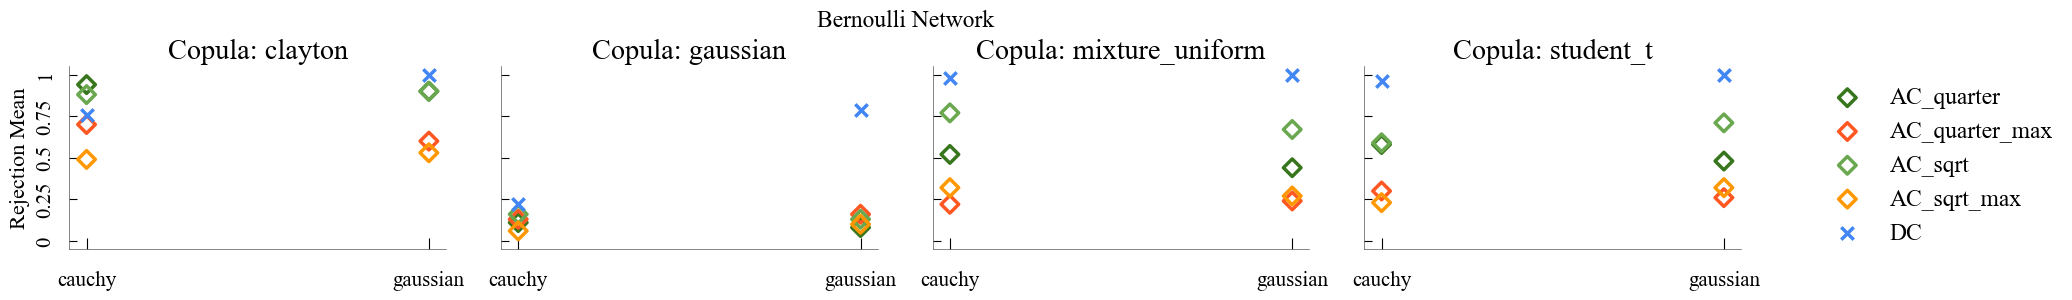

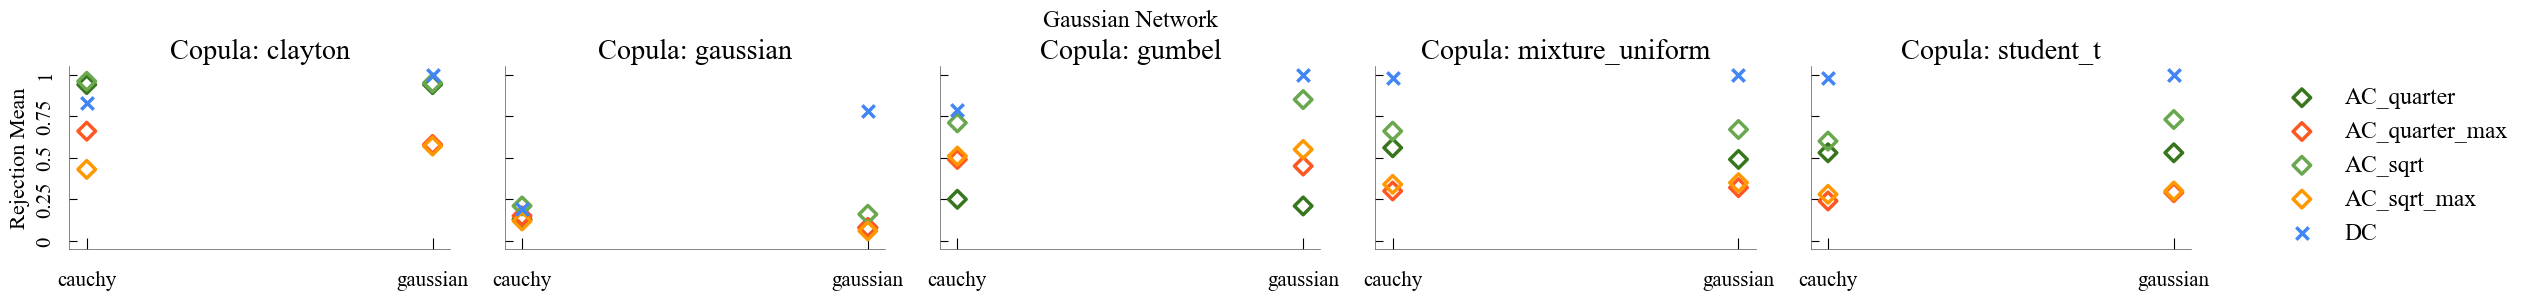

In [466]:
temp = agg_alt_bernoulli.copy()
temp = temp[(temp["use_true_z"] == "False") & (temp["n"] == 400)]
temp = temp[temp['copula'] != 'NA']
temp = temp[temp['marginal_z'].isin(['gaussian'])]
# temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="marginal_x",
    y_axis="Rejection_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Bernoulli Network",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    # x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    # col_order=["gaussian", "clayton", "gumbel", "mixture_uniform"],
)

temp = agg_alt_gaussian.copy()
temp = temp[(temp["use_true_z"] == "False") & (temp["n"] == 400)]
temp = temp[temp['copula'] != 'NA']
temp = temp[temp['marginal_z'].isin(['gaussian'])]
# temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="marginal_x",
    y_axis="Rejection_mean",
    factors=["method", "copula"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=True,
    title="Gaussian Network",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    # x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    # col_order=["gaussian", "clayton", "gumbel", "mixture_uniform"],
)

In [477]:
temp['latent_sim'].value_counts()

latent_sim
bernoulli                  5
circle                     5
two_parabolas              5
step                       5
square                     5
spiral                     5
sin_sixteen_pi             5
quadratic                  5
normal                     5
multimodal_independence    5
log                        5
linear                     5
fourth_root                5
exponential                5
ellipse                    5
diamond                    5
cubic                      5
w_shaped                   5
Name: count, dtype: int64

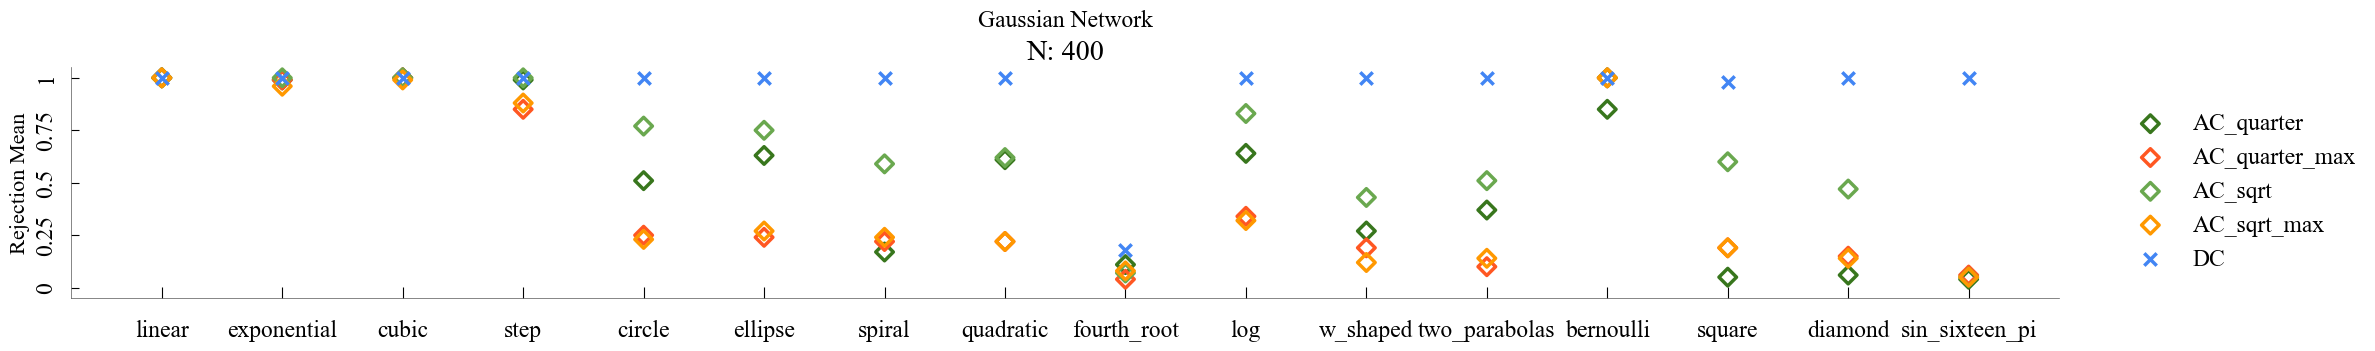

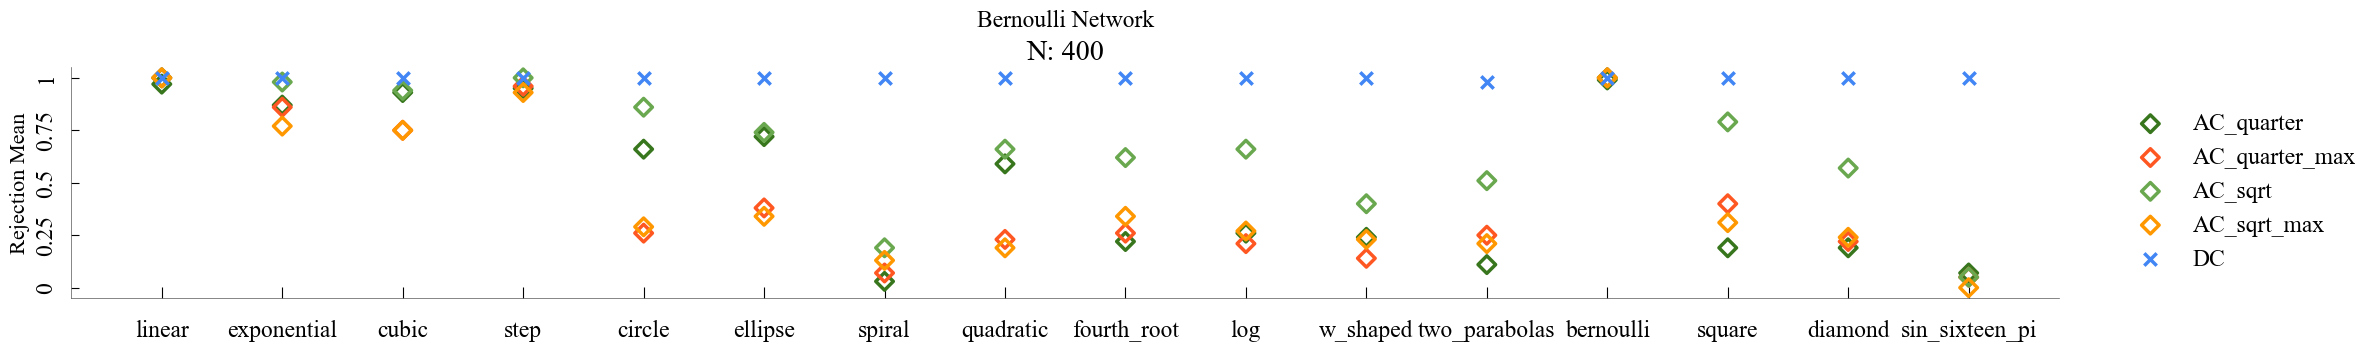

In [482]:
all_sim = [
    "linear",
    "exponential",
    "cubic",
    "step",
    "circle",
    "ellipse",
    "spiral",
    "quadratic",
    "fourth_root",
    "log",
    "w_shaped",
    "two_parabolas",
    "bernoulli",
    "square",
    "diamond",
    "sin_sixteen_pi",
]

temp = agg_alt_gaussian.copy()
temp = temp[temp["n"] == 400]
temp = temp[temp["use_true_z"] == "False"]
temp = temp[temp['latent_sim'].isin(all_sim)]

plot_grid(
    grouped_stats=temp,#[temp["latent_sim"].isin(first_batch)],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)


temp = agg_alt_bernoulli.copy()
temp = temp[temp["n"] == 400]
temp = temp[temp["use_true_z"] == "False"]
temp = temp[temp['latent_sim'].isin(all_sim)]

plot_grid(
    grouped_stats=temp,#[temp["latent_sim"].isin(first_batch)],
    x_axis="latent_sim",
    y_axis="Rejection_mean",
    factors=["method", "n"],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_sim,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Bernoulli Network",
)

In [487]:
agg_alt_gaussian['functional_form'].value_counts()

functional_form
NA              860
abs_max          10
interaction      10
linear           10
manifold         10
max              10
pareto           10
radial           10
sigmoid          10
sine             10
tanh_product     10
Name: count, dtype: int64

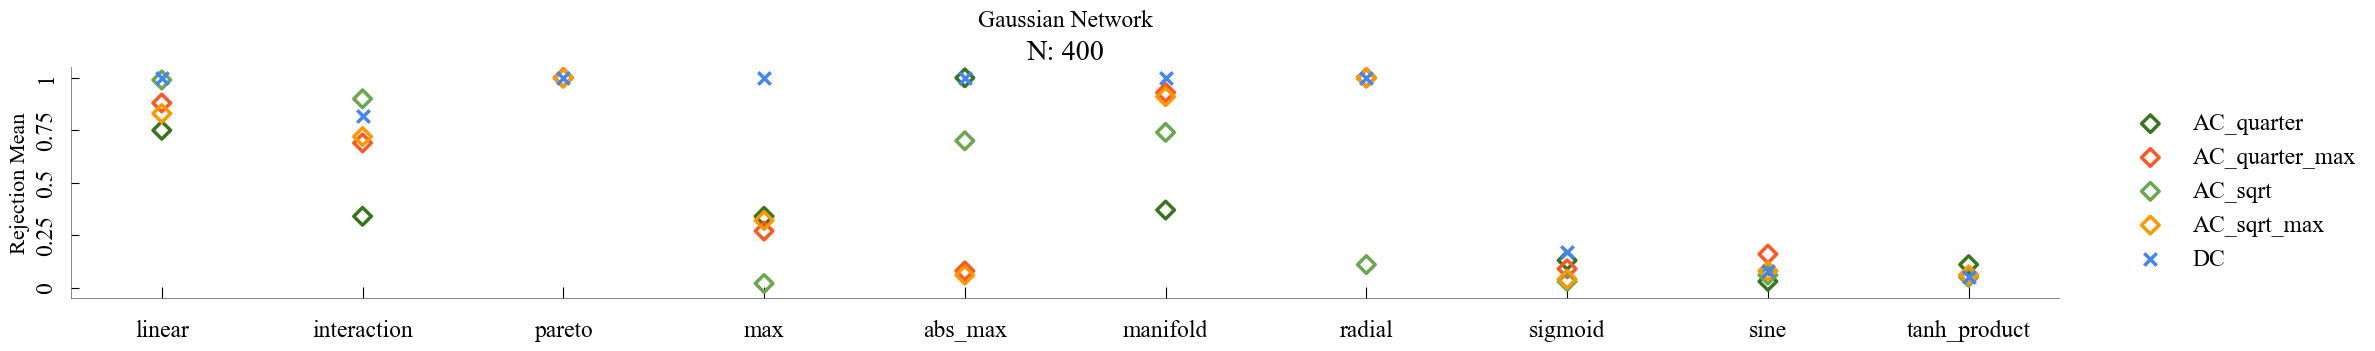

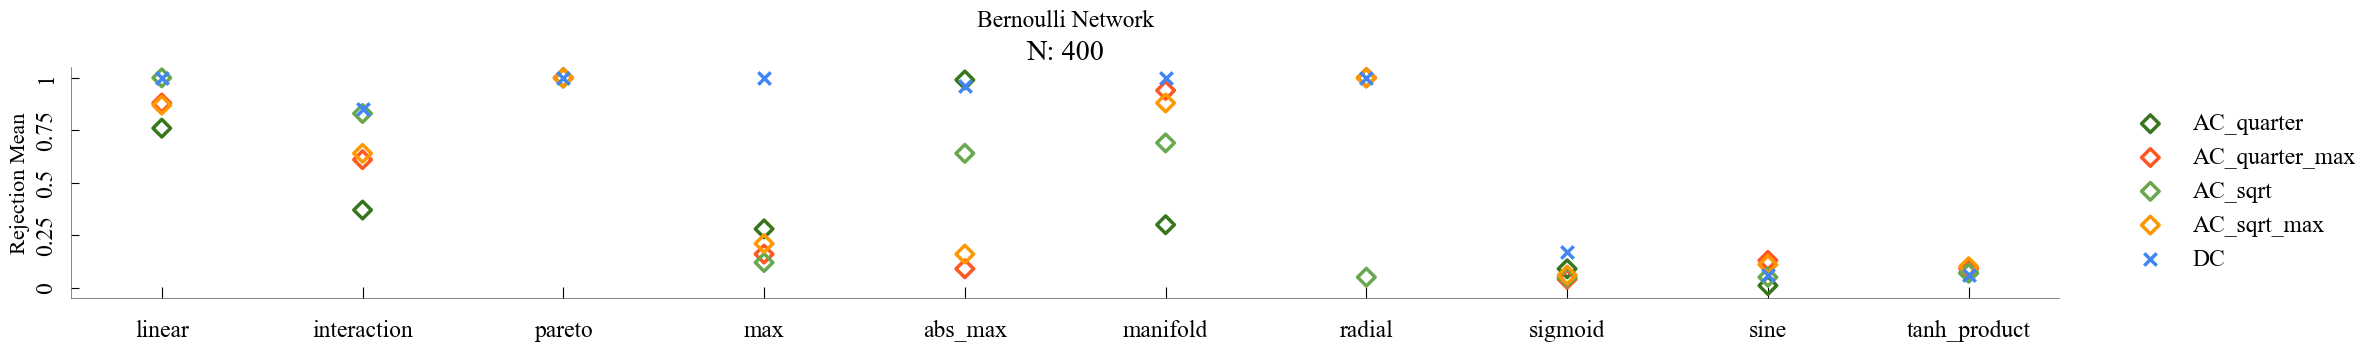

In [491]:
all_functional_forms = [
    "linear",
    "interaction",
    "pareto",
    "max",
    "abs_max",
    "manifold",
    "radial",
    "sigmoid",
    "sine",
    "tanh_product",
]

temp = agg_alt_gaussian.copy()
temp = temp[temp["n"] == 400]
temp = temp[temp["use_true_z"] == "False"]
temp = temp[temp['functional_form'].isin(all_functional_forms)]

plot_grid(
    grouped_stats=temp,
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)


temp = agg_alt_bernoulli.copy()
temp = temp[temp["n"] == 400]
temp = temp[temp["use_true_z"] == "False"]
temp = temp[temp['functional_form'].isin(all_functional_forms)]

plot_grid(
    grouped_stats=temp,
    x_axis="functional_form",
    y_axis="Rejection_mean",
    factors=["method", "n",],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=3.5,
    aspect=6,
    add_legend=True,
    x_order=all_functional_forms,
    show_x_axis_title=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Bernoulli Network",
)

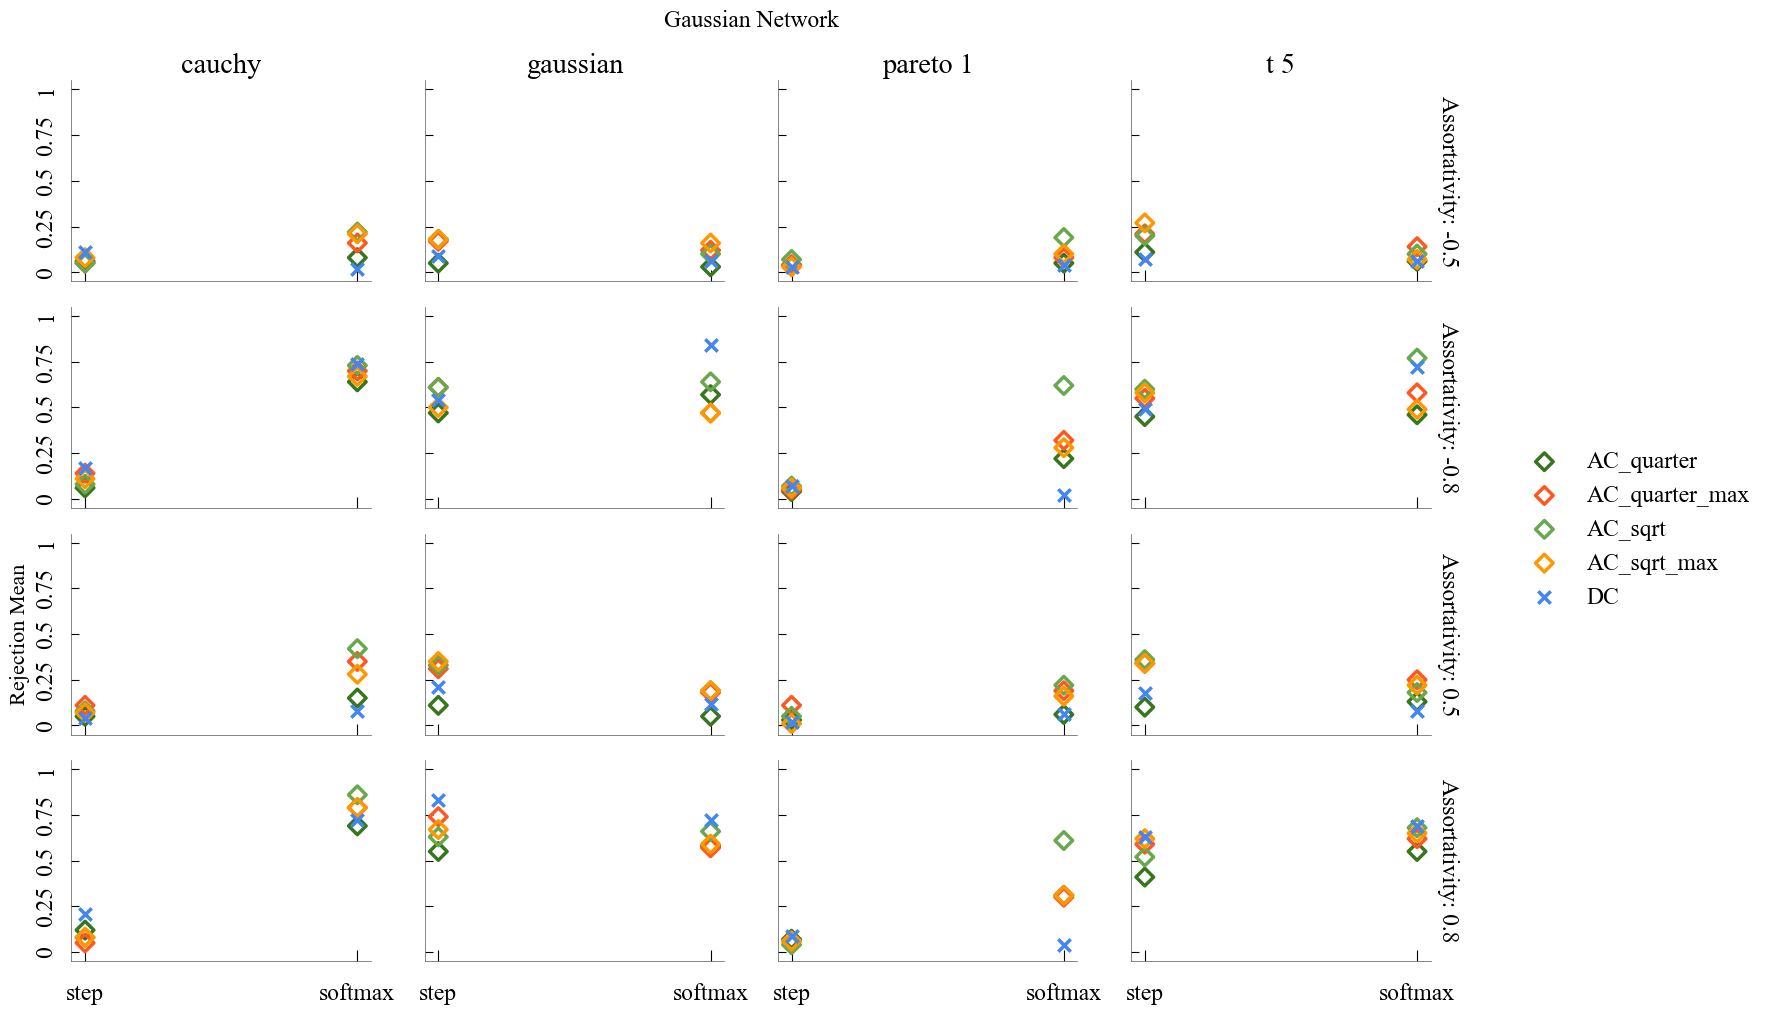

In [ ]:
all_sbm = [
    'step',
    'softmax'
]

temp = agg_alt_gaussian.copy()
temp = temp[temp["n"] == 400]
temp = temp[temp["use_true_z"] == "False"]
temp = temp[temp['sbm_covariate_sampling'].isin(all_sbm)]

plot_grid(
    grouped_stats=temp,
    x_axis="sbm_covariate_sampling",
    y_axis="Rejection_mean",
    factors=["method", "x_distribution", 'assortativity'],
    plotting_function=plot_scatter_markers,
    colors=colors,
    markers=marker_map,
    height=2.5,
    aspect=1.5,
    add_legend=True,
    x_order=all_sbm,
    show_x_axis_title=False,
    show_col_names=False,
    x_tick_labelsize=17,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=17,  # ← same for y (optional)
    x_tick_rotation=0,
    title="Gaussian Network",
)
